In [0]:
%sql
CREATE CATALOG healthcare_catalog;

In [0]:
%sql SHOW CATALOGS;

catalog
airline_catalog
ext_catalog
healthcare_catalog
main
managed_catalog
my-first-bronze-catalog
retail_catalog
samples
system


In [0]:
%sql
USE CATALOG healthcare_catalog;

CREATE SCHEMA healthcare_analytics;

In [0]:
%sql
SHOW SCHEMAS IN healthcare_catalog;

databaseName
default
healthcare_analytics
information_schema


In [0]:
%sql
CREATE VOLUME healthcare_catalog.healthcare_analytics.healthcare_volume;

In [0]:
%sql
SHOW VOLUMES IN healthcare_catalog.healthcare_analytics;

database,volume_name
healthcare_analytics,healthcare_volume


In [0]:
patients_path = "/Volumes/healthcare_catalog/healthcare_analytics/healthcare_volume/patients.csv"

doctors_path = "/Volumes/healthcare_catalog/healthcare_analytics/healthcare_volume/doctors.csv"

appointments_path = "/Volumes/healthcare_catalog/healthcare_analytics/healthcare_volume/appointments.csv"

preferences_path = "/Volumes/healthcare_catalog/healthcare_analytics/healthcare_volume/patient_preferences.json"

In [0]:
patients_df = (
    spark.read
    .option("header","true")
    .option("inferSchema","true")
    .csv(patients_path)
)

In [0]:
doctors_df = (
    spark.read
    .option("header","true")
    .option("inferSchema","true")
    .csv(doctors_path)
)

In [0]:
appointments_df = (
    spark.read
    .option("header","true")
    .option("inferSchema","true")
    .csv(appointments_path)
)

In [0]:
preferences_df = (
    spark.read
    .option("multiline","true")
    .json(preferences_path)
)

In [0]:
patients_df.printSchema()
doctors_df.printSchema()
appointments_df.printSchema()
preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospita

In [0]:
patients_df.write.format("delta").mode("overwrite").saveAsTable(
"healthcare_catalog.healthcare_analytics.bronze_patients")

In [0]:
doctors_df.write.format("delta").mode("overwrite").saveAsTable(
"healthcare_catalog.healthcare_analytics.bronze_doctors")

In [0]:
appointments_df.write.format("delta").mode("overwrite").saveAsTable(
"healthcare_catalog.healthcare_analytics.bronze_appointments")

In [0]:
preferences_df.write.format("delta").mode("overwrite").saveAsTable(
"healthcare_catalog.healthcare_analytics.bronze_preferences")

## Transformations

In [0]:
patients_df = patients_df.na.fill("Unknown")
doctors_df = doctors_df.na.fill("Unknown")
appointments_df = appointments_df.na.fill("Unknown")

In [0]:
from pyspark.sql.functions import col
preferences_flat = preferences_df.select(
    col("patient_id"),
    col("preferred_hospital"),
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)

In [0]:
from pyspark.sql.functions import col

doctors_df_renamed = doctors_df.withColumnRenamed(
    "city",
    "doctor_city"
)

final_df = appointment_patient_df.join(
    doctors_df_renamed,
    "doctor_id",
    "left"
)

In [0]:
patient_pref_df = patients_df.join(
    preferences_flat,
    "patient_id",
    "left"
)

In [0]:
appointment_patient_df = appointments_df.join(
    patient_pref_df,
    "patient_id",
    "left"
)

In [0]:
final_df = appointment_patient_df.join(
    doctors_df,
    "doctor_id",
    "left"
)

In [0]:
from pyspark.sql.functions import *
final_df = final_df.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
)

In [0]:
final_df = final_df.withColumn(
    "appointment_month",
    date_format(
        to_date("appointment_date"),
        "yyyy-MM"
    )
)

In [0]:
final_df = final_df.withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)

In [0]:
display(final_df)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,doctor_name,department,city,consultation_fee,final_bill,appointment_month,patient_age_group
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult


In [0]:
final_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable(
"healthcare_catalog.healthcare_analytics.silver_appointments"
)

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-7960112318146382>, line 4
      1 final_df.write \
      2 .format("delta") \
      3 .mode("overwrite") \
----> 4 .saveAsTable(
      5 "healthcare_catalog.healthcare_analytics.silver_appointments"
      6 )

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/readwriter.py:737, in DataFrameWriter.saveAsTable(self, name, format, mode, partitionBy, **options)
    735 self._write.table_name = name
    736 self._write.table_save_method = "save_as_table"
--> 737 _, _, ei = self._spark.client.execute_command(
    738     self._write.command(self._spark.client), self._write.observations
    739 )
    740 self._callback(ei)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
 

In [0]:
final_df.printSchema()

root
 |-- doctor_id: string (nullable = false)
 |-- patient_id: string (nullable = false)
 |-- appointment_id: string (nullable = false)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = false)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = false)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: integer (nullable = true)
 |-- appointment_month: string (nullable = true)
 |-- patient_age_group: string (nullable = false)



In [0]:
new_cols = []

city_count = 0

for c in final_df.columns:
    if c == "city":
        city_count += 1
        if city_count == 1:
            new_cols.append("patient_city")
        else:
            new_cols.append("doctor_city")
    else:
        new_cols.append(c)

final_df = final_df.toDF(*new_cols)

In [0]:
final_df.printSchema()

root
 |-- doctor_id: string (nullable = false)
 |-- patient_id: string (nullable = false)
 |-- appointment_id: string (nullable = false)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = false)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = false)
 |-- patient_name: string (nullable = true)
 |-- patient_city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- doctor_city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: integer (nullable = true)
 |-- appointment_month: string (nullable = true)
 |-- patient_age_group: string (nullable = false)



In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "healthcare_catalog.healthcare_analytics.silver_appointments"
    )

In [0]:
%sql
SHOW TABLES IN healthcare_catalog.healthcare_analytics;

database,tableName,isTemporary
healthcare_analytics,bronze_appointments,false
healthcare_analytics,bronze_doctors,false
healthcare_analytics,bronze_patients,false
healthcare_analytics,bronze_preferences,false
healthcare_analytics,silver_appointments,false


## Spark SQL

In [0]:
final_df.createOrReplaceTempView("hospital_analytics")

In [0]:
%sql
SELECT
SUM(final_bill) AS total_revenue
FROM hospital_analytics;

total_revenue
69200


In [0]:
%sql
SELECT
department,
SUM(final_bill) AS revenue
FROM hospital_analytics
GROUP BY department
ORDER BY revenue DESC;

department,revenue
Cardiology,33000
Orthopedics,21500
Dermatology,6500
Neurology,5500
Pediatrics,2700


In [0]:
%sql
SELECT
patient_city,
SUM(final_bill) AS revenue
FROM hospital_analytics
GROUP BY patient_city
ORDER BY revenue DESC;

patient_city,revenue
Hyderabad,23000
Delhi,21500
Pune,10000
Bangalore,5500
Kochi,3500
Mumbai,3000
Chennai,2700


In [0]:
%sql
SELECT *
FROM hospital_analytics
WHERE status='Completed';

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,phone,email,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult


In [0]:
%sql
SELECT
patient_name,
SUM(final_bill) AS total_billing
FROM hospital_analytics
GROUP BY patient_name
ORDER BY total_billing DESC;

patient_name,total_billing
Sneha Patel,21500
Rahul Sharma,16000
Neha Singh,10000
Arjun Verma,7000
Priya Reddy,5500
Meera Nair,3500
Amit Kumar,3000
Farhan Ali,2700


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import sum, rank

doctor_revenue = final_df.groupBy(
    "doctor_name"
).agg(
    sum("final_bill").alias("revenue")
)

window_spec = Window.orderBy(
    doctor_revenue["revenue"].desc()
)

doctor_rank = doctor_revenue.withColumn(
    "rank",
    rank().over(window_spec)
)

display(doctor_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


doctor_name,revenue,rank
Dr. Suresh,21500,1
Dr. Kiran,19500,2
Dr. Ramesh,13500,3
Dr. Anita,6500,4
Dr. Priya,5500,5
Dr. Meera,2700,6


In [0]:
department_revenue = final_df.groupBy(
    "department"
).agg(
    sum("final_bill").alias("revenue")
)

window_spec = Window.orderBy(
    department_revenue["revenue"].desc()
)

department_rank = department_revenue.withColumn(
    "rank",
    rank().over(window_spec)
)

display(department_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


department,revenue,rank
Cardiology,33000,1
Orthopedics,21500,2
Dermatology,6500,3
Neurology,5500,4
Pediatrics,2700,5


In [0]:
from pyspark.sql.functions import dense_rank

patient_revenue = final_df.groupBy(
    "patient_name"
).agg(
    sum("final_bill").alias("billing")
)

window_spec = Window.orderBy(
    patient_revenue["billing"].desc()
)

top_patients = patient_revenue.withColumn(
    "rank",
    dense_rank().over(window_spec)
).filter("rank <= 3")

display(top_patients)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


patient_name,billing,rank
Sneha Patel,21500,1
Rahul Sharma,16000,2
Neha Singh,10000,3


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
from pyspark.sql.functions import row_number
doctor_department = final_df.groupBy(
    "department",
    "doctor_name"
).agg(
    sum("final_bill").alias("revenue")
)

window_spec = Window.partitionBy(
    "department"
).orderBy(
    doctor_department["revenue"].desc()
)

top_doctor = doctor_department.withColumn(
    "rn",
    row_number().over(window_spec)
).filter("rn=1")

display(top_doctor)

department,doctor_name,revenue,rn
Cardiology,Dr. Kiran,19500,1
Dermatology,Dr. Anita,6500,1
Neurology,Dr. Priya,5500,1
Orthopedics,Dr. Suresh,21500,1
Pediatrics,Dr. Meera,2700,1


In [0]:
daily_revenue = final_df.groupBy(
    "appointment_date"
).agg(
    sum("final_bill").alias("daily_revenue")
)

In [0]:
window_spec = Window.orderBy(
    "appointment_date"
)

running_revenue = daily_revenue.withColumn(
    "running_revenue",
    sum("daily_revenue").over(window_spec)
)

display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


appointment_date,daily_revenue,running_revenue
2026-06-01,12000,12000
2026-06-02,17500,29500
2026-06-03,12700,42200
2026-06-04,10500,52700
2026-06-05,16500,69200


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


## Delta Lake

In [0]:
final_df.write \
.format("delta") \
.mode("overwrite") \
.save(
"/Volumes/healthcare_catalog/healthcare_analytics/healthcare_volume/delta_df_write"
)

In [0]:
final_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable(
"healthcare_catalog.healthcare_analytics.delta_saveastable"
)

In [0]:
%sql
CREATE TABLE healthcare_catalog.healthcare_analytics.delta_sql
USING DELTA
AS
SELECT *
FROM healthcare_catalog.healthcare_analytics.silver_appointments;

num_affected_rows,num_inserted_rows


In [0]:
%sql
DESCRIBE HISTORY healthcare_catalog.healthcare_analytics.silver_appointments;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T06:35:31.000Z,143016486184747,atsthasneem@gmail.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1534042518472241),d5f7c971-d342-491a-abd5-65570d423e7d,0622-034211-f57zxtke-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7288)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql
SELECT *
FROM healthcare_catalog.healthcare_analytics.silver_appointments
VERSION AS OF 0;

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,phone,email,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult


In [0]:
updated_patient = spark.createDataFrame(
[
("P101","Bangalore","Inactive"),
("P102","Chennai","Active")
],
[
"patient_id",
"patient_city",
"insurance_status"
]
)

updated_patient.createOrReplaceTempView(
"updated_patient"
)

In [0]:
%sql
select * from updated_patient;

patient_id,patient_city,insurance_status
P101,Bangalore,Inactive
P102,Chennai,Active


In [0]:
%sql
MERGE INTO healthcare_catalog.healthcare_analytics.silver_appointments t
USING updated_patient s
ON t.patient_id = s.patient_id

WHEN MATCHED THEN
UPDATE SET
t.patient_city = s.patient_city,
t.insurance_status = s.insurance_status;

num_affected_rows,num_updated_rows,num_deleted_rows,num_inserted_rows
3,3,0,0


In [0]:
%sql
DESCRIBE HISTORY healthcare_catalog.healthcare_analytics.silver_appointments;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T07:26:13.000Z,143016486184747,atsthasneem@gmail.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(1534042518472241),304fbf6e-f66e-4db3-9374-0d6d9e215389,0622-034211-f57zxtke-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 2, numRemovedBytes -> 13813, p25FileSize -> 7376, numDeletionVectorsRemoved -> 1, minFileSize -> 7376, numAddedFiles -> 1, maxFileSize -> 7376, p75FileSize -> 7376, p50FileSize -> 7376, numAddedBytes -> 7376)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T07:26:11.000Z,143016486184747,atsthasneem@gmail.com,MERGE,"Map(predicate -> [""(patient_id#29093 = patient_id#29045)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [])",null,List(1534042518472241),304fbf6e-f66e-4db3-9374-0d6d9e215389,0622-034211-f57zxtke-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 6525, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 3, executionTimeMs -> 3948, materializeSourceTimeMs -> 90, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1526, numTargetRowsUpdated -> 3, numOutputRows -> 3, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 2, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2236)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T06:35:31.000Z,143016486184747,atsthasneem@gmail.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1534042518472241),d5f7c971-d342-491a-abd5-65570d423e7d,0622-034211-f57zxtke-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7288)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql
OPTIMIZE healthcare_catalog.healthcare_analytics.silver_appointments;

path,metrics
abfss://metastore@atsdatabricksunity.dfs.core.windows.net/9b7405bb-8507-45c6-b943-4779a4db7886/tables/3fdc30ce-a34b-4873-ae87-8f1d1edeed09,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782113199537, 1782113199914, 8, 0, null, List(0, 0), null, 23, 23, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE healthcare_catalog.healthcare_analytics.silver_appointments
ZORDER BY (patient_id);

path,metrics
abfss://metastore@atsdatabricksunity.dfs.core.windows.net/9b7405bb-8507-45c6-b943-4779a4db7886/tables/3fdc30ce-a34b-4873-ae87-8f1d1edeed09,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 7376), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782113208055, 1782113208438, 8, 0, null, List(0, 0), null, 23, 23, 0, 0, null, null)"


In [0]:
%sql
VACUUM healthcare_catalog.healthcare_analytics.silver_appointments
RETAIN 168 HOURS;

path
abfss://metastore@atsdatabricksunity.dfs.core.windows.net/9b7405bb-8507-45c6-b943-4779a4db7886/tables/3fdc30ce-a34b-4873-ae87-8f1d1edeed09


## Visualization

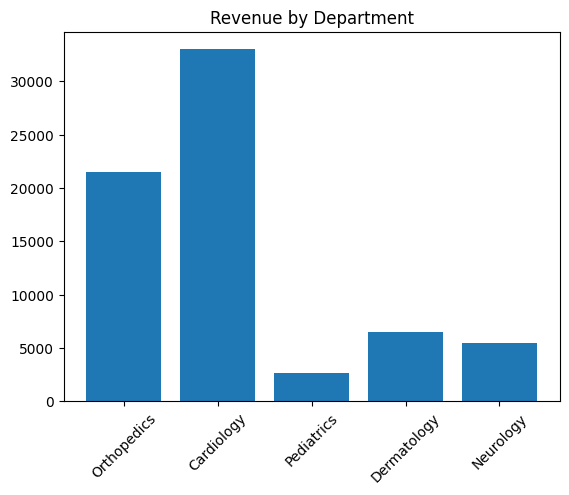

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

dept_df = final_df.groupBy(
    "department"
).agg(
    sum("final_bill").alias("revenue")
)

pdf = dept_df.toPandas()

plt.bar(pdf["department"], pdf["revenue"])
plt.title("Revenue by Department")
plt.xticks(rotation=45)
plt.show()

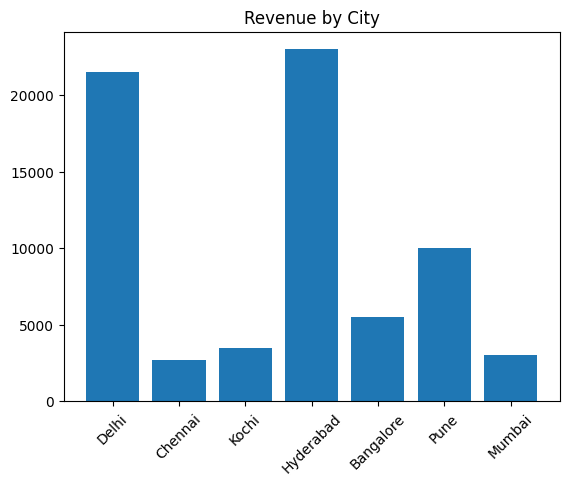

In [0]:
city_df = final_df.groupBy(
    "patient_city"
).agg(
    sum("final_bill").alias("revenue")
)

pdf = city_df.toPandas()

plt.bar(pdf["patient_city"], pdf["revenue"])
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

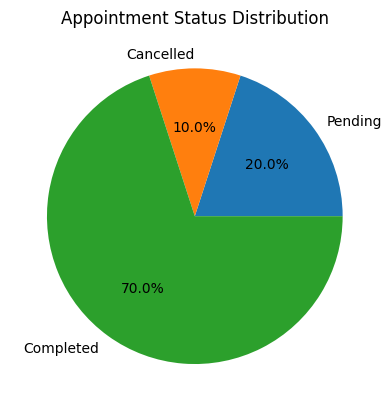

In [0]:
status_df = final_df.groupBy(
    "status"
).count()

pdf = status_df.toPandas()

plt.pie(
    pdf["count"],
    labels=pdf["status"],
    autopct="%1.1f%%"
)

plt.title("Appointment Status Distribution")
plt.show()

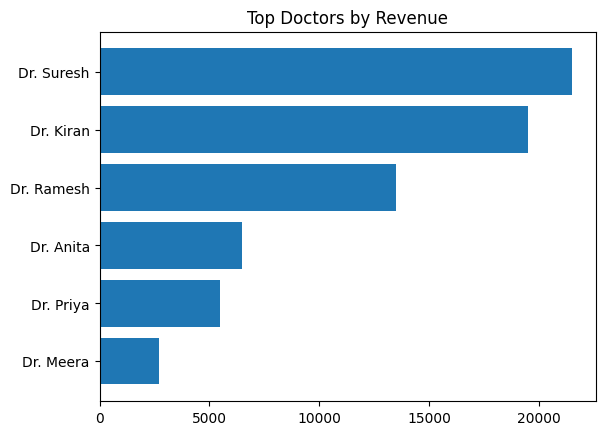

In [0]:
doctor_df = final_df.groupBy(
    "doctor_name"
).agg(
    sum("final_bill").alias("revenue")
)

pdf = doctor_df.toPandas()

pdf = pdf.sort_values(
    "revenue",
    ascending=True
)

plt.barh(
    pdf["doctor_name"],
    pdf["revenue"]
)

plt.title("Top Doctors by Revenue")
plt.show()

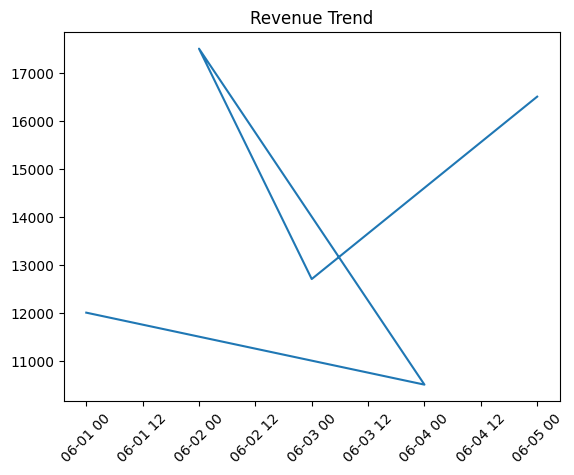

In [0]:
trend_df = final_df.groupBy(
    "appointment_date"
).agg(
    sum("final_bill").alias("revenue")
)

pdf = trend_df.toPandas()

plt.plot(
    pdf["appointment_date"],
    pdf["revenue"]
)

plt.title("Revenue Trend")
plt.xticks(rotation=45)
plt.show()

## Tables and Views

In [0]:
%sql
CREATE TABLE healthcare_catalog.healthcare_analytics.managed_hospital
USING DELTA
AS
SELECT *
FROM hospital_analytics;

num_affected_rows,num_inserted_rows


In [0]:
%sql
CREATE TABLE healthcare_catalog.healthcare_analytics.external_hospital
USING DELTA
LOCATION 'abfss://raw@atsdatabricksunity.dfs.core.windows.net/healthcare_external'
AS
SELECT *
FROM hospital_analytics;

num_affected_rows,num_inserted_rows


In [0]:
%sql
CREATE OR REPLACE TEMP VIEW temp_hospital AS
SELECT *
FROM hospital_analytics;

## 